Task 3：從局域原子波包組出 Bloch-like 波形，連到 bonding / antibonding 圖像 

In [300]:
# 引入模組
import numpy as np
import matplotlib.pyplot as plt

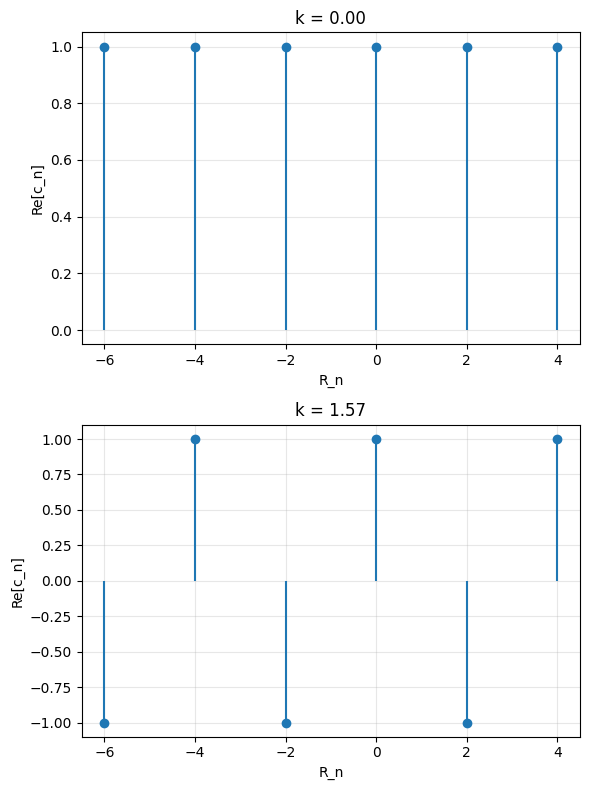

In [301]:
# 3.1 先做相位預測
## 一些參數設定
a = 2.0
n = np.arange(-3, 3)      # 6 個晶格點
R = n * a

k_values = [0, np.pi/a]

# 畫圖ㄌㄚˋ (axes 為由子圖組成的2*1矩陣)
fig, axes = plt.subplots(2, 1, figsize=(6, 8))
# 一個迴圈一次掃描所有k，因為我很懶
for i, k in enumerate(k_values):
    
    c_n = np.exp(1j * k * R)
    
    # 用實部表示（看正負最直觀）
    axes[i].stem(R, np.real(c_n), basefmt=" ")
    
    axes[i].set_title(f"k = {k:.2f}")
    axes[i].set_xlabel("R_n")
    axes[i].set_ylabel("Re[c_n]")
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

相鄰晶格點上的波函數是同號還是交替變號？哪一個 k 會讓相鄰原子之間的 density 增
加？哪一個 k 會讓它降低？

ANS:

1.在k=0時，波函數為同號（皆為＋１），k=π/a時，相鄰晶格點上的波函數交替變號。

2.由於k=0時，波函數相鄰點為同相，彼此疊加，為建設性干涉，因此原子間density增加，而k=π/a時，波函數相鄰點為反相，會互相抵銷，因此原子間density降低。

In [302]:
# 3.2 建立 Bloch-like 疊加態
## 一些參數設定
alpha = 1      # 局域波包寬度
N = 6            # 晶格點數量（左右各 N 個）
n = np.arange(-N, N+1)
R = n * a
# 範圍
x = np.linspace(-10, 10, 4000)

In [ ]:
# 局域波包
def phi(x):
    return np.exp(-np.abs(x)/alpha)

# 建立 Bloch-like 疊加態
def psi_k(x, k):
    psi = np.zeros_like(x, dtype=complex)
    for Rn in R:
        psi += np.exp(1j * k * Rn) * phi(x - Rn)

# normalization
    dx = x[1] - x[0]
    norm = np.sqrt(np.sum(np.abs(psi)**2) * dx)
    
    psi = psi / norm
    
    return psi

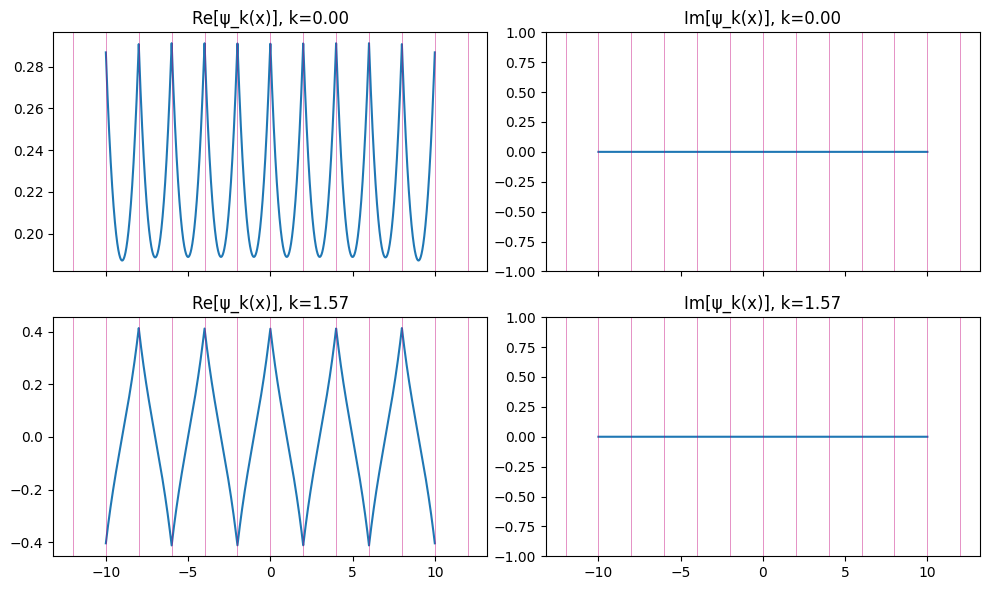

In [304]:
k_list = [0, np.pi/a]

# 畫圖ㄌㄚˋ
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
for i, k in enumerate(k_list):
    psi = psi_k(x, k)
    # Re
    axes[i, 0].plot(x, np.real(psi))
    axes[i, 0].set_title(f"Re[ψ_k(x)], k={k:.2f}")
    axes[i, 0].grid(alpha=0)
    # Im
    axes[i, 1].plot(x, np.imag(psi))
    axes[i,1].set_ylim(-1, 1)
    axes[i, 1].set_title(f"Im[ψ_k(x)], k={k:.2f}")
    axes[i, 1].grid(alpha=0)
# 標出晶格點
for ax in axes.ravel():
    for Rn in R:
        ax.axvline(Rn, color='#C20078', linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.show()

k=0：
由實部的圖可以看出，相鄰原子的波函數沒有變號，表示所有原子皆為同相，原子間建設性疊加，數學上則代表e＾ikRn​=1，又e＾i0=1，表示波函數為一個純實數，因此虛部的圖幾乎等於0。

k = π/a ≈ 1.57
由實部的圖可以看出，相鄰原子的波函數正負交替，表示相鄰原子皆為反相，原子間相互抵銷，為破壞性干涉，並且兩原子中間出現數值為0的節點。而同樣，由於e＾ikRn​=e＾iπn=(−1)＾n為實數，因此虛部的圖幾乎等於0。

<function matplotlib.pyplot.show(close=None, block=None)>

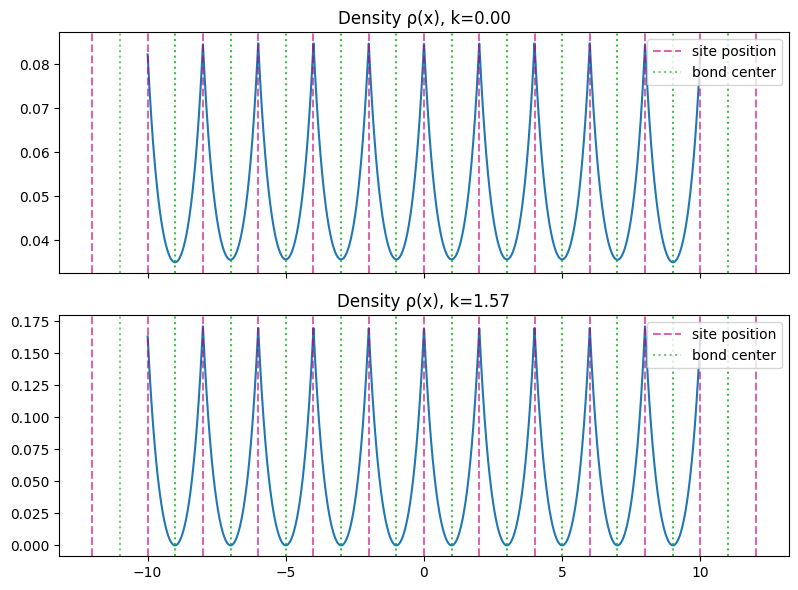

In [305]:
# 3.3 比較機率密度 
# 畫圖ㄌㄚˋ
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
for i, k in enumerate(k_list):
    psi = psi_k(x, k)
    # 機率密度
    axes[i].plot(x, np.abs(psi)**2)
    # 標記原子位置(site position Rₙ)
    for j, Rn in enumerate(R):
        if j == 0:
            axes[i].axvline(Rn, linestyle='--', color='#C20078', alpha=0.6, label='site position')
        else:
            axes[i].axvline(Rn, linestyle='--', color='#C20078', alpha=0.6)
    # 標記bond center((Rₙ+Rₙ₊₁)/2)
    bond_centers = (R[:-1] + R[1:]) / 2
    for j, bc in enumerate(bond_centers):
        if j == 0:
            axes[i].axvline(bc, linestyle=':',color='#15B01A', alpha=0.6, label='bond center')
        else:
            axes[i].axvline(bc, linestyle=':', color='#15B01A', alpha=0.8)

    axes[i].set_title(f'Density ρ(x), k={k:.2f}')
    axes[i].legend(loc='upper right')
    axes[i].grid(alpha=0)
plt.tight_layout()
plt.show

In [306]:
# 讀density數值
def rho_k(x, k):
    return np.abs(psi_k(x, k))**2
    
def density (x, rho, positions):
    return np.interp(positions, x, rho)

# 選中間幾個點避免邊界效應
sites = R[2:-2]
bonds = (R[2:-2] + R[3:-1]) / 2

In [307]:
for k in k_list:
    psi = psi_k(x, k)
    rho = np.abs(psi)**2

    site_vals = density(x, rho, sites)
    bond_vals = density(x, rho, bonds)

    print(f"\n=== k = {k:.2f} ===")
    print(f"Site density avg  = {np.mean(site_vals):.4f}")
    print(f"Bond density avg  = {np.mean(bond_vals):.4f}")


=== k = 0.00 ===
Site density avg  = 0.0846
Bond density avg  = 0.0356

=== k = 1.57 ===
Site density avg  = 0.1696
Bond density avg  = 0.0000


由上圖以及讀出的數據可知，site position的機率密度較大，bond center的機率密度較小，且k=0的Bond density＝0。

又知一開始設定之局域波包函數ϕ為e＾−∣x−Rn​∣/α，波函數為(e^ikRn)*（e＾−∣x−Rn​∣/α），因此當在site position（x = Rₙ）時，ϕ(0)=1，波函數最大，而在bond center（x = (Rₙ + Rₙ₊₁)/2），ϕ(±a/2)<1，波函數較小，又因k = π/a時相鄰兩原子反相，在bond center就會接近完全抵消，因此波函數機率密度為零。

In [ ]:
# 3.4 定量觀察鍵中心 density
## # 選中間幾個點避免邊界效應
sites_pos = R[2:-2]
bonds_pos = (R[2:-2] + R[3:-1]) / 2

def sample_rho(x, rho, pos):
    return np.interp(pos, x, rho)

def B(k):
    rho = rho_k(x, k)
    rho_site = sample_rho(x, rho, site_pos)
    rho_bond = sample_rho(x, rho, bond_pos)
    return rho_bond - rho_site, rho_site, rho_bond

k = 0.000
  rho(site) = 0.084633
  rho(bond) = 0.035680
  B(k)      = -0.048954

k = 1.571
  rho(site) = 0.169071
  rho(bond) = 0.000001
  B(k)      = -0.169070



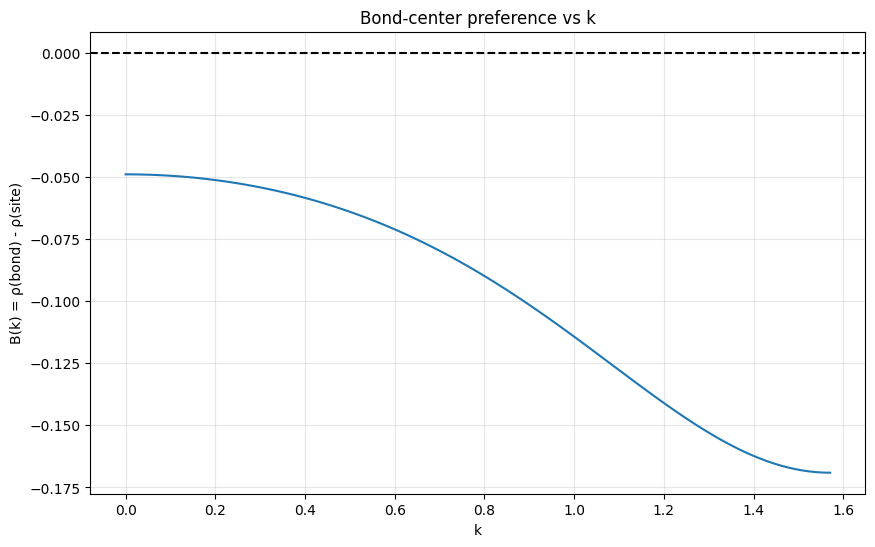

In [309]:
# 數值比較
k_list = [0, np.pi/a]

for k in k_list:
    Bk, rs, rb = B(k)
    print(f"k = {k:.3f}")
    print(f"  rho(site) = {rs:.6f}")
    print(f"  rho(bond) = {rb:.6f}")
    print(f"  B(k)      = {Bk:.6f}\n")

# 畫圖ㄌㄚˋ
k_scan = np.linspace(0, np.pi/a, 100)
B_vals = [B(k)[0] for k in k_scan]

plt.figure(figsize=(10,6))
plt.plot(k_scan, B_vals)
plt.axhline(0, linestyle='--', color='black')
plt.xlabel('k')
plt.ylabel('B(k) = ρ(bond) - ρ(site)')
plt.title('Bond-center preference vs k')
plt.grid(alpha=0.3)
plt.show()

由上圖以及讀出的數值可以看出，k=0時，B(k) 較大，電子較不局域，而是分布在原子間，物理上為bonding-like，而k=π/a時，電子強烈局域在原子上，物理上為antibonding-like，這張圖顯示了一維 tight-binding 中 bonding → antibonding 的連續轉變，可以觀察到當 k 由 0 增加到 π/a 時，相鄰原子間的相位差逐漸增加，使原本在原子間的建設性干涉逐漸減弱，轉為破壞性干涉，因此系統由 bonding-like 逐漸過渡到 antibonding-like。

In [310]:
# 3.5 改變波包局域程度 α
alpha_list = [0.4, 0.8, 1.6]  
dx = x[1] - x[0]

def phi(x, alpha):
    return np.exp(-np.abs(x)/alpha)

def psi_k(x, k, alpha):
    psi = np.zeros_like(x, dtype=complex)
    for Rn in R:
        psi += np.exp(1j * k * Rn) * phi(x - Rn, alpha)
    norm = np.sqrt(np.sum(np.abs(psi)**2) * dx)
    psi = psi / norm
    return psi

def rho_k(x, k, alpha):
    return np.abs(psi_k(x, k, alpha))**2

In [311]:
def region_density(rho, x, centers, width):
    total = 0.0
    for c in centers:
        mask = (x > c - width/2) & (x < c + width/2)
        total += np.sum(rho[mask]) * dx
    return total / len(centers)

# 中間區域避免邊界效應
sites = R[3:-3]
bonds = (R[3:-3] + R[4:-2]) / 2
width = a/2


=== alpha = 0.4 ===
k = 0.000 | site = 0.0891, bond = 0.0108, B = -0.0783
k = 1.571 | site = 0.0947, bond = 0.0051, B = -0.0896


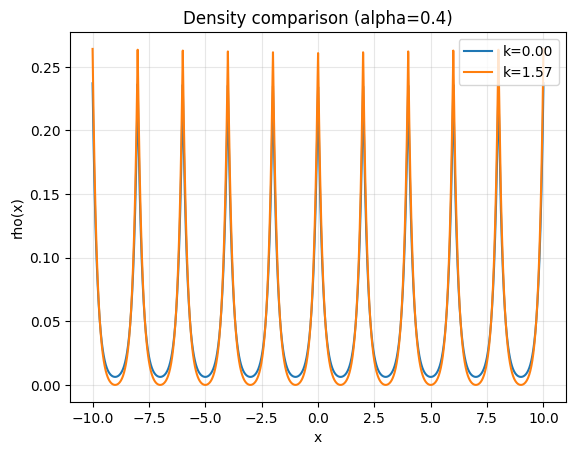


=== alpha = 0.8 ===
k = 0.000 | site = 0.0667, bond = 0.0334, B = -0.0333
k = 1.571 | site = 0.0901, bond = 0.0099, B = -0.0802


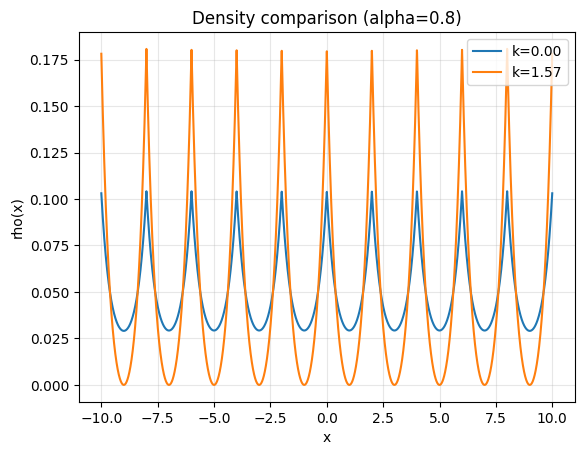


=== alpha = 1.6 ===
k = 0.000 | site = 0.0557, bond = 0.0461, B = -0.0097
k = 1.571 | site = 0.0885, bond = 0.0119, B = -0.0766


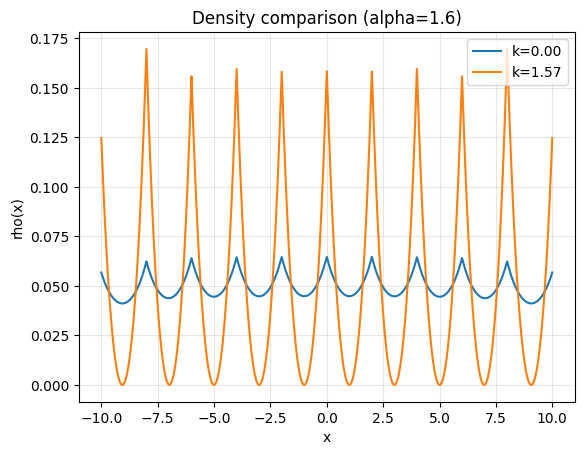

In [312]:
# ===== 計算與畫圖 =====
k_values = [0, np.pi/a]

for alpha in alpha_list:
    print(f"\n=== alpha = {alpha} ===")
    
    for k in k_values:
        rho = rho_k(x, k, alpha)
        
        rho_site = region_density(rho, x, sites, width)
        rho_bond = region_density(rho, x, bonds, width)
        B = rho_bond - rho_site
        
        print(f"k = {k:.3f} | site = {rho_site:.4f}, bond = {rho_bond:.4f}, B = {B:.4f}")

    # 畫 density 對比
    plt.figure()
    for k in k_values:
        rho = rho_k(x, k, alpha)
        plt.plot(x, rho, label=f"k={k:.2f}")
    
    plt.title(f"Density comparison (alpha={alpha})")
    plt.xlabel("x")
    plt.ylabel("rho(x)")
    plt.legend(loc="upper right")
    plt.grid(alpha=0.3)
    plt.show()

由上圖可以看出，當α很小時，bond density 很低，表示相鄰原子的重疊減少，使得電子在原子間的干涉效應變弱，因此k=0 與 k=π/a 幾乎重疊，而當α逐漸上升，相鄰原子重疊增強，干涉效應變強，k=0的bond也逐漸增加，k=0 與 k=π/a 的 density 分布差異更加顯著，這對應到 tight-binding 圖像中，重疊減小會使 hopping 參數變小，進而導致能帶變窄。

總結：

k= 0時相鄰原子同相，彼此之間為建設性干涉，電子分佈較不局域，而是分布在原子間，因此鍵中心 density較高，物理上為bonding-like，而k = π/a 時相鄰原子反相，鍵中心因破壞性干涉幾乎抵銷殆盡，電子強烈局域在原子上，因此鍵中心 density 較低，是 antibonding-like。 在比較不同k值對 bonding 或 antibonding 的影響時，因為原子位置和鍵中心的density是此消彼長的關係，且相鄰原子之間的density跟bonding才有直接關係，所以應先看相鄰原子之間的density，而不是只看原子位置峰值。